In [1]:
# CELL 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("All libraries loaded!")

All libraries loaded!


In [2]:
# CELL 2 - Load Data
df = pd.read_excel(r'C:\Users\Lenovo\Documents\dev\data-science-projects\00_customer_segmentation\data\online_retail.xlsx')

print("Shape:", df.shape)
df.head()



Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# CELL 3 - Check Missing Values
print("Missing values:")
print(df.isnull().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# CELL 4 — Clean the data
# Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (Invoice starts with 'C') and negative quantities
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert CustomerID to integer (cleaner to work with)
df['CustomerID'] = df['CustomerID'].astype(int)

print("Cleaned shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())




Cleaned shape: (397884, 8)

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [5]:
# CELL 5 — Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Sample with TotalPrice:")
df.head()



Sample with TotalPrice:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [6]:
# updated shape
print("Cleaned shape:", df.shape)

Cleaned shape: (397884, 9)


In [7]:
#Step 4: Build RFM Features

In [8]:
# CELL 6 — Set the reference date
# We calculate "recency" relative to the day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)
print("Date range in data:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Reference date: 2011-12-10 12:50:00
Date range in data: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [9]:
# CELL 7 — Build the RFM table
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print("RFM shape:", rfm.shape)
print("\nSample:")
rfm.head(10)

RFM shape: (4338, 4)

Sample:


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [10]:
# CELL 8 — Check the distributions
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [ ]:
# Step 5: Handle Skew + Scale the Data

In [11]:
# CELL 9 — Fix the skew with log transformation
rfm_log = rfm.copy()

rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

rfm_log[['Recency','Frequency','Monetary']].describe()





,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.593627
std,1.340261,0.683104,1.257578
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.731446
50%,3.951244,1.098612,6.515431
75%,4.962845,1.791759,7.416222
max,5.926926,5.347108,12.543284


In [12]:
# CELL 10 — Scale to equal range
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

# Convert back to dataframe for readability
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Scaled data sample:")
rfm_scaled.describe()

Scaled data sample:


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,2.817274e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-4.004574e+00
25%,-6.613615e-01,-9.552143e-01,-6.856676e-01
50%,8.992557e-02,-3.615828e-01,-6.218718e-02
75%,8.447915e-01,6.532370e-01,6.541861e-01
max,1.564198e+00,5.858535e+00,4.731591e+00


In [ ]:
# Step 6: Find the Best K — Elbow Method

In [13]:
# CELL 11 — Calculate inertia for each K
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

print("Inertia values:")
for k, val in zip(k_range, inertia):
    print(f"  K={k}: {val:.2f}")

Inertia values:
  K=2: 6481.23
  K=3: 4867.85
  K=4: 3938.51
  K=5: 3295.98
  K=6: 2855.01
  K=7: 2548.91
  K=8: 2336.78
  K=9: 2155.65
  K=10: 1999.90


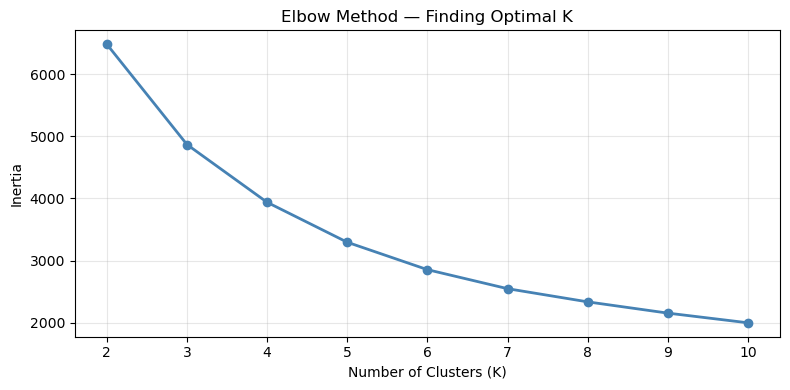

In [14]:
# CELL 12 — Plot the Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Confirm with Silhouette Score

In [15]:
# Cell 13 — Silhouette scores
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_scores.append(score)
    print(f"  K={k}: Silhouette Score = {score:.4f}")

  K=2: Silhouette Score = 0.4329
  K=3: Silhouette Score = 0.3365
  K=4: Silhouette Score = 0.3371
  K=5: Silhouette Score = 0.3161
  K=6: Silhouette Score = 0.3133
  K=7: Silhouette Score = 0.3100
  K=8: Silhouette Score = 0.3008
  K=9: Silhouette Score = 0.2817
  K=10: Silhouette Score = 0.2787


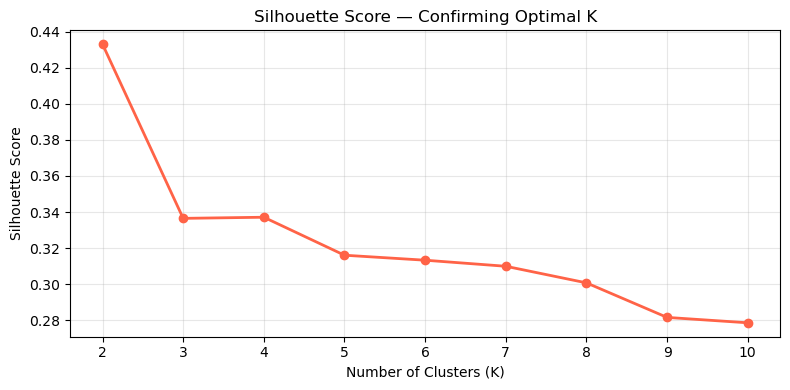

In [16]:
#Cell 14 — Plot silhouette scores
plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker='o', color='tomato', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Confirming Optimal K')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Run the Final K-Means Model

In [17]:
# Cell 15 — Fit with K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

print("Customers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

Customers per cluster:
Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64


In [18]:
# Cell 16 — Cluster profiles
cluster_summary = rfm.groupby('Cluster').agg(
    Recency   = ('Recency',   'mean'),
    Frequency = ('Frequency', 'mean'),
    Monetary  = ('Monetary',  'mean'),
    Count     = ('CustomerID','count')
).round(1)

print(cluster_summary)

         Recency  Frequency  Monetary  Count
Cluster                                     
0           18.1        2.1     551.8    837
1           12.1       13.7    8074.3    716
2           71.1        4.1    1802.8   1173
3          182.5        1.3     343.5   1612


In [ ]:
# Step 8: Visualize the Clusters

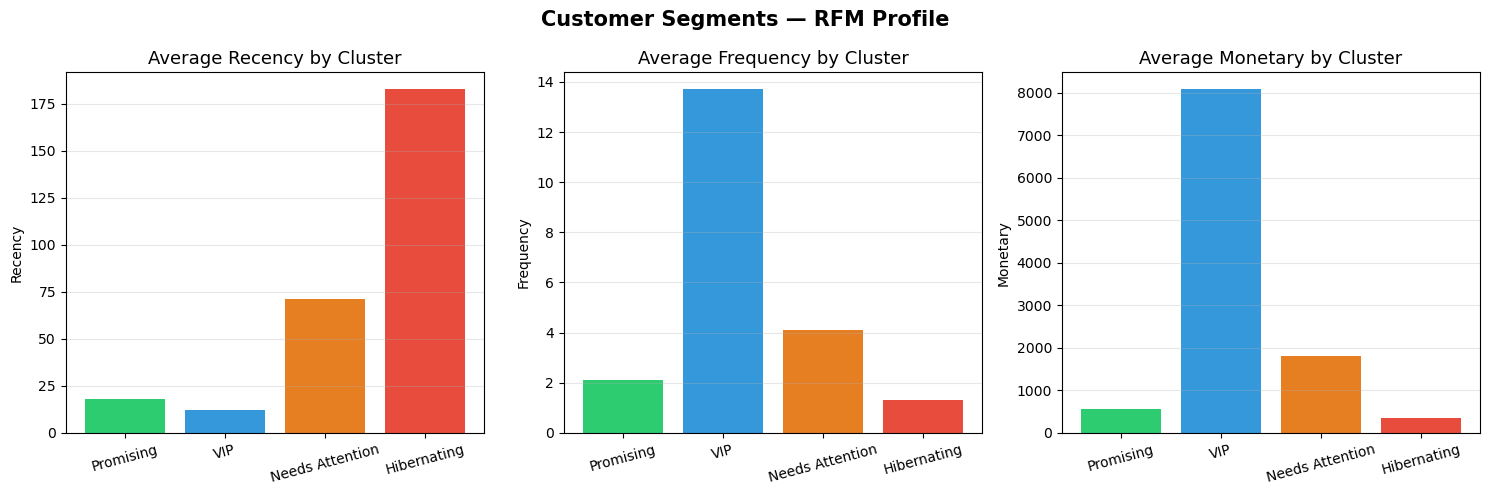

In [19]:
# Cell 17 — Bar chart of cluster profiles
cluster_summary_plot = rfm.groupby('Cluster').agg(
    Recency=('Recency','mean'),
    Frequency=('Frequency','mean'),
    Monetary=('Monetary','mean')
).round(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2ecc71','#3498db','#e67e22','#e74c3c']
labels = ['Promising','VIP','Needs Attention','Hibernating']

for i, col in enumerate(['Recency','Frequency','Monetary']):
    axes[i].bar(labels, cluster_summary_plot[col], color=colors)
    axes[i].set_title(f'Average {col} by Cluster', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Customer Segments — RFM Profile', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

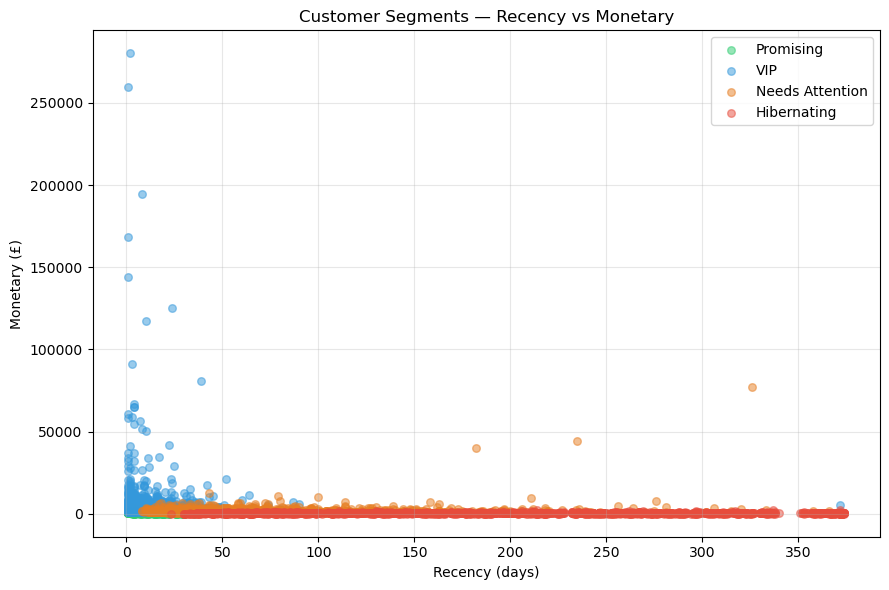

In [20]:
# Cell 18 — Scatter plot (Recency vs Monetary)
colors_map = {0:'#2ecc71', 1:'#3498db', 2:'#e67e22', 3:'#e74c3c'}
label_map  = {0:'Promising', 1:'VIP', 2:'Needs Attention', 3:'Hibernating'}

plt.figure(figsize=(9, 6))
for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Monetary'],
                c=colors_map[cluster], label=label_map[cluster],
                alpha=0.5, s=30)

plt.xlabel('Recency (days)')
plt.ylabel('Monetary (£)')
plt.title('Customer Segments — Recency vs Monetary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Final Step: Save Your Results

In [22]:
# Cell 19 — Add labels and save to CSV

# Merge segment labels onto the full cleaned transaction dataframe
df_segmented = df.merge(
    rfm[['CustomerID', 'Cluster', 'Segment']],
    on='CustomerID',
    how='left'
)

print("Shape:", df_segmented.shape)
print("\nSample:")
df_segmented.head()

Shape: (397884, 11)

Sample:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cluster,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,1,VIP
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,VIP
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,1,VIP
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,VIP
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,VIP


In [23]:
# Cell 20 — Final summary for your README/portfolio

# File 1 — One row per customer (marketing list)
rfm.to_csv(
    r'C:\Users\Lenovo\Documents\dev\data-science-projects\00_customer_segmentation\outputs\rfm_segments.csv',
    index=False
)

# File 2 — Full transactions with segment column
df_segmented.to_csv(
    r'C:\Users\Lenovo\Documents\dev\data-science-projects\00_customer_segmentation\outputs\transactions_segmented.csv',
    index=False
)

print("Both files saved successfully!")
print(f"\nFile 1 — rfm_segments.csv:         {len(rfm):,} rows (one per customer)")
print(f"File 2 — transactions_segmented.csv: {len(df_segmented):,} rows (all transactions)")

Both files saved successfully!

File 1 — rfm_segments.csv:         4,338 rows (one per customer)
File 2 — transactions_segmented.csv: 397,884 rows (all transactions)


In [24]:
# Cell 21 — Quick sense check

# Confirm segments are mapped correctly across both files
print("=== File 1 — Customer Segments ===")
print(rfm['Segment'].value_counts())

print("\n=== File 2 — Transactions per Segment ===")
print(df_segmented['Segment'].value_counts())

print("\nSample of merged file:")
df_segmented[['InvoiceNo','CustomerID','TotalPrice','Segment']].head(10)

=== File 1 — Customer Segments ===
Segment
Hibernating        1612
Needs Attention    1173
Promising           837
VIP                 716
Name: count, dtype: int64

=== File 2 — Transactions per Segment ===
Segment
VIP                211054
Needs Attention    108684
Promising           40607
Hibernating         37539
Name: count, dtype: int64

Sample of merged file:


,InvoiceNo,CustomerID,TotalPrice,Segment
0,536365,17850,15.30,VIP
1,536365,17850,20.34,VIP
2,536365,17850,22.00,VIP
3,536365,17850,20.34,VIP
4,536365,17850,20.34,VIP
5,536365,17850,15.30,VIP
6,536365,17850,25.50,VIP
7,536366,17850,11.10,VIP
8,536366,17850,11.10,VIP
9,536367,13047,54.08,VIP
